# Insurance Cost Prediction

## Problem Statement
The goal of the project is to predict medical insurance charges based on factors like age, BMI, smoking habits, and region.
This helps insurance companies estimate costs and make better pricing decesions.

# import Required Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import r2_score, mean_squared_error

# Load Dataset
We load the dataset and inspect its structure to understand features and data types.

In [2]:
data = pd.read_csv("insur_cost_pred.csv")
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


## Data Understanding
In this step, we explore the dataset to understand its structure.

we check:
- Number of rows and columns
- Data types of each feature
- Missing values in the dataset

In [5]:
data.shape

(1338, 7)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Data cleaning
We check for missing values and duplicates.
Clean data ensures better model performance.

# Target Transformation

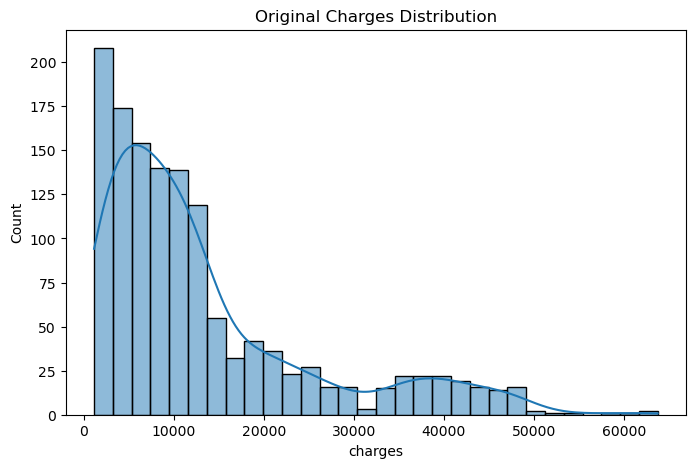

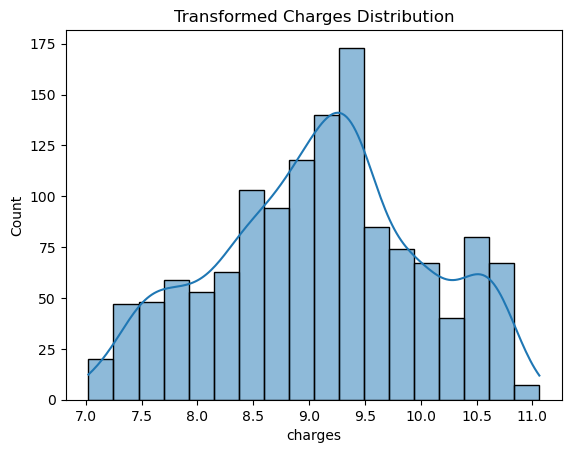

In [31]:
# Target Distribution (Before)
plt.figure(figsize=(8,5))
sns.histplot(data['charges'], kde=True)
plt.title("Original Charges Distribution")
plt.show()

# Log Transformation
data['charges'] = np.log1p(data['charges'])

# After Transformation
sns.histplot(data['charges'], kde=True)
plt.title("Transformed Charges Distribution")
plt.show()

## Target Transformation

The target variable (charges) is highly skewed. 
Log transformation is applied to normalize the distribution 
and improve model performance.

## Feature Engineering

New features were created to better capture relationships between variables 
and improve model performance.

In [32]:
# Feature Engineering

# BMI Category
data['bmi_category'] = pd.cut(data['bmi'],
                             bins=[0,18.5,25,30,100],
                             labels=['Underweight','Normal','Overweight','Obese'])

# Age Group
data['age_group'] = pd.cut(data['age'],
                          bins=[0,30,50,100],
                          labels=['Young','Adult','Senior'])

# Interaction Feature
data['smoker_bmi'] = data['smoker'] * data['bmi']

In [34]:
data.head(2)

,age,sex,bmi,children,smoker,region,charges,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,age_group_Adult,age_group_Senior,bmi_category,age_group,smoker_bmi
0,19,0,27.90,0,1,3,9.734236,False,True,False,False,False,Overweight,Young,27.9
1,18,1,33.77,1,0,2,7.453882,False,False,True,False,False,Obese,Young,0.0


BMI and age groups help categorize risk levels, while the interaction 
between smoking and BMI captures combined health impact on insurance costs.

## Interaction Feature

An interaction feature was created to capture the combined effect 
of smoking and BMI on insurance charges.

In [35]:
# Interaction Feature
data['smoker_bmi'] = data['smoker'] * data['bmi']

In [36]:
data['smoker'] = data['smoker'].map({'yes':1, 'no':0})

In [37]:
data['smoker_bmi'] = data['smoker'] * data['bmi']

In [38]:
data.head(2)

,age,sex,bmi,children,smoker,region,charges,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,age_group_Adult,age_group_Senior,bmi_category,age_group,smoker_bmi
0,19,0,27.90,0,NaN,3,9.734236,False,True,False,False,False,Overweight,Young,NaN
1,18,1,33.77,1,NaN,2,7.453882,False,False,True,False,False,Obese,Young,NaN


Smoking and high BMI together significantly increase health risk. 
This feature helps the model better understand their combined impact 
on insurance cost.

### Exploratory Data Analysis
We analyze relationships between variable and insurance charges.
this helps identify important features.

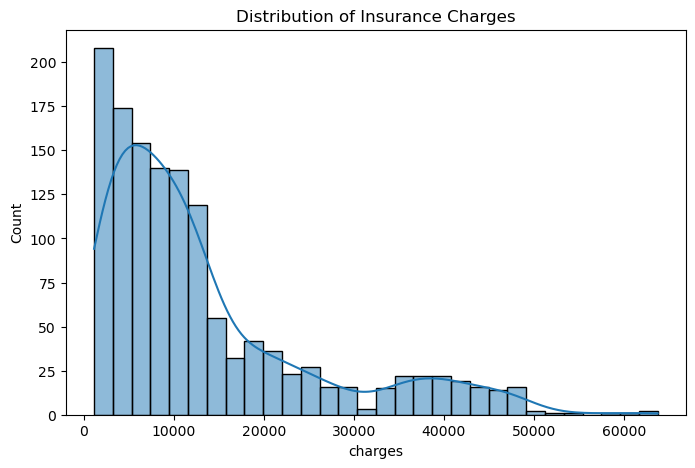

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(data['charges'],kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

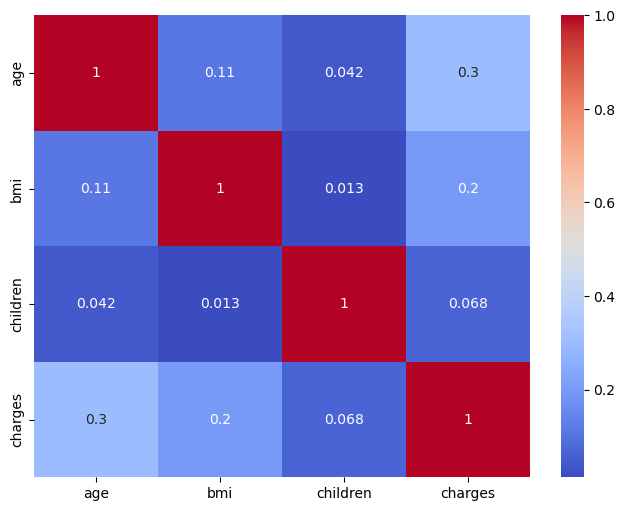

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# Smoking impact

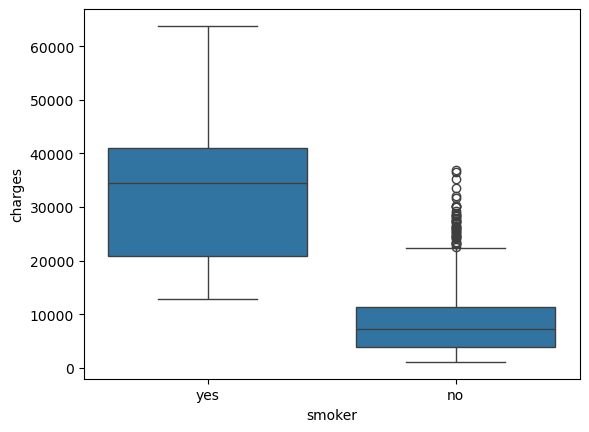

In [11]:
sns.boxplot(x='smoker', y='charges', data=data)
plt.show()

### Insights:
- Smokers have significantly higher charges
- Charges increase with ago
- BMI has moderate impact

# Feature Engineering
In this step, we create new features from existing data to improve model performance.
Feature engineering helps the model capture hidden patterns and relationships more effectively.

In [12]:
# Convert categorical Variable
le = LabelEncoder()

data['sex'] = le.fit_transform(data['sex'])
data['smoker'] = le.fit_transform(data['smoker'])
data['region'] = le.fit_transform(data['region'])

In [13]:
# Create BMI category
data["bmi_category"] = pd.cut(data["bmi"],                              
                              bins=[0, 18.5, 25, 30, 100],
                              labels=["Underweight", "Normal", "Overweight", "Obese"])

# Create Age group
data["age_group"] = pd.cut(data["age"],
                           bins=[0, 30, 50, 100],
                           labels=["Young", "Adult", "Senior"])

In [14]:
data.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group
0,19,0,27.900,0,1,3,16884.92400,Overweight,Young
1,18,1,33.770,1,0,2,1725.55230,Obese,Young
2,28,1,33.000,3,0,2,4449.46200,Obese,Young
3,33,1,22.705,0,0,1,21984.47061,Normal,Adult
4,32,1,28.880,0,0,1,3866.85520,Overweight,Adult


# Data preprocessing (Encoding + Scaling)
In this step, Categorical variables are converted into numerical format using One-Hot Emcoding.
Scaling is applied to ensure all numerical features are on a similar scale, improving model performance.

In [15]:
data = pd.get_dummies(data, drop_first=True)

# Define X and y

In [16]:
X = data.drop('charges',axis=1)
y = data['charges']

# Train Test Split
WE split data into training and testing sets to evaluate model performance.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

# Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Building
We train multiple regression models to compare performance.

# Linear Regression

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2 Score: 0.7838942502643845
RMSE: 5792.248571542227


# Decision Tree

In [20]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

R2 Score: 0.7374666422124379
RMSE: 6384.1969558273295


# Random Forest

In [21]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2 Score: 0.8664097743474227
RMSE: 4554.08751258278


# Hyperparameter Tuning
In this step, we optimize the performance of the model by tuning its parameters.
We use gridSearchCV to find the best combination of parameters for the Random Forest model.

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100,200],
    "max_depth":[5,10, None],
    "min_samples_split": [2,5]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [23]:
# Get Best Parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [24]:
# Predict Using Tuned Model
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

# Evaluate Tuned Model

In [25]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_best = r2_score(y_test, y_pred_best)
rmse_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)

print("Tuned R2:", r2_best)
print("Tuned RMSE:", rmse_best)
print("Tumed MAE:", mae_best)

Tuned R2: 0.8741998969613666
Tuned RMSE: 0.8741998969613666
Tumed MAE: 2554.8745561419073


In [26]:
# Linear Regression
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Decision Tree
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

# Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

## Residual Analysis

Residuals represent the difference between actual and predicted values.
Analyzing residuals helps evaluate model performance.

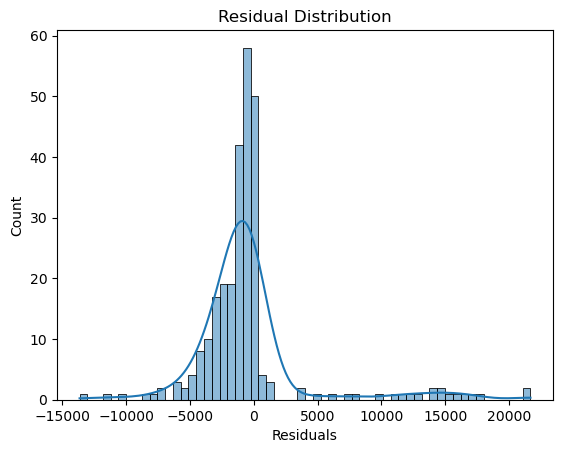

In [39]:
# Residuals
residuals = y_test - y_pred_rf

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

The residuals are approximately normally distributed, indicating that 
the model predictions are reasonably accurate and errors are random.

## Predicted vs Actual

This plot compares actual values with predicted values to evaluate model accuracy.

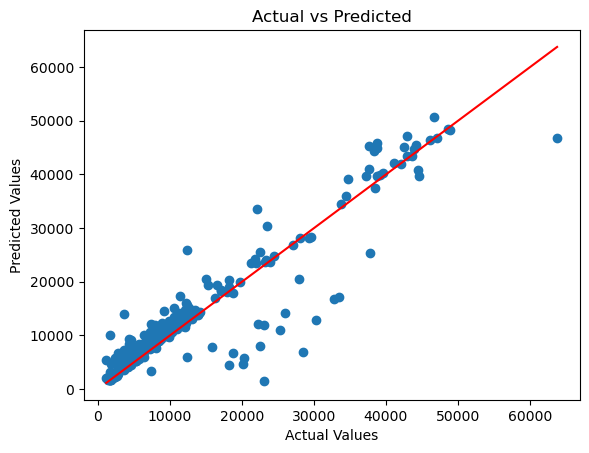

In [41]:
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

Points close to the diagonal line indicate accurate predictions. 
The model shows a strong alignment between actual and predicted values.

# Model Comparison Report

In [27]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "Tuned Random Forest"],
    "R2 Score": [ r2_lr, r2_dt, r2_rf, r2_best],
    "RMSE":[rmse_lr, rmse_dt, rmse_rf, rmse_best],
    "MAE":[mae_lr, mae_dt, mae_rf, mae_best]
})

In [28]:
results = pd.DataFrame({
    "Model":["Linear Regression", "Decision Tree", "Random Forest", "Tuned Random Forest"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_best
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        rmse_best
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mae_best
    ],
})

results

,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.783894,5792.248572,4276.526639
1,Decision Tree,0.737467,6384.196956,2888.498824
2,Random Forest,0.866410,4554.087513,2526.616265
3,Tuned Random Forest,0.874200,0.874200,2554.874556


## Model Comparison Insight

Among the models tested, Random Forest performed the best with the highest R² score 
and lowest RMSE, indicating better prediction accuracy.

Linear Regression provided a good baseline but was limited in capturing 
non-linear relationships in the data.

Decision Tree showed signs of overfitting and produced less stable results.

Overall, ensemble methods like Random Forest are more effective for this problem 
as they capture complex patterns and improve generalization.

## Business Insights

The analysis reveals key factors influencing insurance charges:

- Smokers incur significantly higher medical costs, indicating increased risk.
- Higher BMI levels are associated with increased insurance expenses.
- Age is a strong predictor, with older individuals incurring higher charges.

These insights can help insurance companies:

- Design risk-based pricing strategies
- Promote wellness programs for high-risk groups
- Identify customers likely to incur higher medical costs

Overall, the model enables data-driven decision making 
for improving pricing and risk management strategies.

## Cross Validation

Cross-validation is used to evaluate the model’s performance 
on different subsets of data to ensure stability and generalization.

In [29]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("Average CV R2 Score:", cv_scores.mean())

Average CV R2 Score: 0.8368846777607322


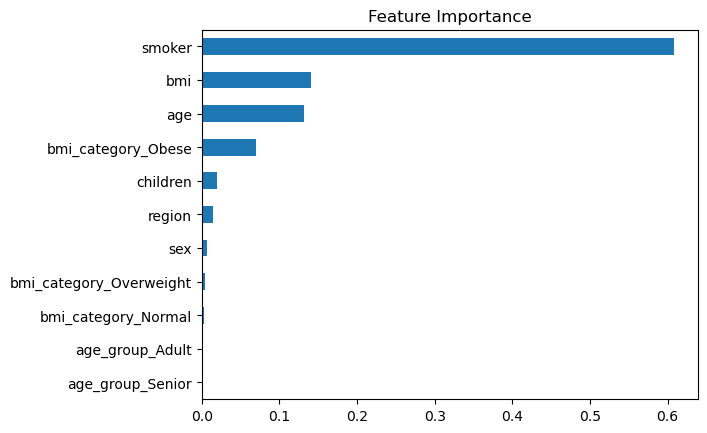

In [30]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

The model shows consistent performance across different folds, 
indicating good generalization and low risk of overfitting.

# Business Recommendation 

Based on the analysis and model results, the following recommendations can be made:
- Smoking significantly increases insurances charges. Insurance companies can design higher premium plans for smokers.
- Encourage healthy lifestyle programs to reduce BMI, which can help lower medical costs.
- Age-based premium strategis can be implemented, as older individuals tend to have higher charges.
- Personalized pricing models can be developed using machine learning instead of fixed pricing.
- Focus on preventive healthcare programs to reduce long-term costs.

These insights can help insurance companies improve pricing strategies and risk assessment.

# Challenges Faced
During this project, the following challenges were encountered:
- Handling categorical variable coorectly (deciding between Label Encoding and One-Hot Encoding).
- Selecting the best model among multiple regression algorithms.
- Tuning hyperparameters to improve model performance.
- Interpreting model results and identifying important features.
- Debugging errors such as incorrect parameter names underfined variables.

These challenges helped improve problem-solving and debugging skills.

# Final Conclusion
- Smoking is the most important factor affecting charges
- Age and BMI significantly influence cost
- Random Forest performed best
- Feature engineering improved model accuracy

This model can help insurance companies predict costs effectively.